# Liquid Push-T

Architecture: A **Closed-form Continuous-time (CfC)** cell — the canonical Liquid Time-Constant network — implemented from scratch in PyTorch (no external `ncps` dependency required).
The CfC cell solves the LTC ODE in closed form:

$$x(t) = \sigma\!\left(W_f \cdot [x_{t-1}, u_t] + b_f\right) \odot x_{t-1} + \sigma\!\left(W_h \cdot [x_{t-1}, u_t] + b_h\right) \odot \tanh\!\left(W_c \cdot [x_{t-1}, u_t] + b_c\right)$$

This avoids ODE solvers and runs at transformer-comparable speed while retaining continuous-time inductive bias.

## 1. Install and Import Dependencies

In [ ]:
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# Install any missing packages (most are already in the venv)
pip_install("gdown", "zarr", "pymunk", "shapely", "scikit-image", "imageio", "gymnasium", "tqdm", "seaborn", "diffusers")
print("All dependencies ready.")

All dependencies ready.


In [1]:
import os
import math
import collections
import zipfile

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import random_split
import zarr
import gdown
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print(f"PyTorch {torch.__version__}  |  device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch 2.10.0  |  device: cpu


## 2. Download and Extract Dataset

In [4]:
# download demonstration data from Google Drive
dataset_path = "pusht_cchi_v7_replay.zarr.zip"
extracted_dataset_path = "pusht_cchi_v7_replay.zarr"  # Path to extracted dataset

if not os.path.isfile(dataset_path):
    id = "1KY1InLurpMvJDRb14L9NlXT_fEsCvVUq&confirm=t"
    gdown.download(id=id, output=dataset_path, quiet=False)

# Extract the dataset if it hasn't been extracted yet
if not os.path.isdir(extracted_dataset_path):
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_dataset_path)

print("Dataset ready at:", extracted_dataset_path)

Dataset ready at: pusht_cchi_v7_replay.zarr


## 3. Dataset Utilities and PushTStateDataset

In [2]:
def create_sample_indices(
        episode_ends:np.ndarray, sequence_length:int,
        pad_before: int=0, pad_after: int=0):
    indices = list()
    for i in range(len(episode_ends)):
        start_idx = 0
        if i > 0:
            start_idx = episode_ends[i-1]
        end_idx = episode_ends[i]
        episode_length = end_idx - start_idx

        min_start = -pad_before
        max_start = episode_length - sequence_length + pad_after

        # range stops one idx before end
        for idx in range(min_start, max_start+1):
            buffer_start_idx = max(idx, 0) + start_idx
            buffer_end_idx = min(idx+sequence_length, episode_length) + start_idx
            start_offset = buffer_start_idx - (idx+start_idx)
            end_offset = (idx+sequence_length+start_idx) - buffer_end_idx
            sample_start_idx = 0 + start_offset
            sample_end_idx = sequence_length - end_offset
            indices.append([
                buffer_start_idx, buffer_end_idx,
                sample_start_idx, sample_end_idx])
    indices = np.array(indices)
    return indices


def sample_sequence(train_data, sequence_length,
                    buffer_start_idx, buffer_end_idx,
                    sample_start_idx, sample_end_idx):
    result = dict()
    for key, input_arr in train_data.items():
        sample = input_arr[buffer_start_idx:buffer_end_idx]
        data = sample
        if (sample_start_idx > 0) or (sample_end_idx < sequence_length):
            data = np.zeros(
                shape=(sequence_length,) + input_arr.shape[1:],
                dtype=input_arr.dtype)
            if sample_start_idx > 0:
                data[:sample_start_idx] = sample[0]
            if sample_end_idx < sequence_length:
                data[sample_end_idx:] = sample[-1]
            data[sample_start_idx:sample_end_idx] = sample
        result[key] = data
    return result

# normalize data
def get_data_stats(data):
    data = data.reshape(-1,data.shape[-1])
    stats = {
        'min': np.min(data, axis=0),
        'max': np.max(data, axis=0)
    }
    return stats

def normalize_data(data, stats):
    # normalize to [0,1]
    ndata = (data - stats['min']) / (stats['max'] - stats['min'])
    # normalize to [-1, 1]
    ndata = ndata * 2 - 1
    return ndata

def unnormalize_data(ndata, stats):
    ndata = (ndata + 1) / 2
    data = ndata * (stats['max'] - stats['min']) + stats['min']
    return data

# dataset
class PushTStateDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path,
                 pred_horizon, obs_horizon, action_horizon):

        # read from zarr dataset
        dataset_root = zarr.open(dataset_path, mode='r')
        # All demonstration episodes are concatenated in the first dimension N
        train_data = {
            # (N, action_dim)
            'action': dataset_root['data']['action'][:],
            # (N, obs_dim)
            'obs': dataset_root['data']['state'][:]
        }
        # Marks one-past the last index for each episode
        episode_ends = dataset_root['meta']['episode_ends'][:]

        # compute start and end of each state-action sequence
        # also handles padding
        indices = create_sample_indices(
            episode_ends=episode_ends,
            sequence_length=pred_horizon,
            # add padding such that each timestep in the dataset are seen
            pad_before=obs_horizon-1,
            pad_after=action_horizon-1)

        # compute statistics and normalized data to [-1,1]
        stats = dict()
        normalized_train_data = dict()
        for key, data in train_data.items():
            stats[key] = get_data_stats(data)
            normalized_train_data[key] = normalize_data(data, stats[key])

        self.indices = indices
        self.stats = stats
        self.normalized_train_data = normalized_train_data
        self.pred_horizon = pred_horizon
        self.action_horizon = action_horizon
        self.obs_horizon = obs_horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        buffer_start_idx, buffer_end_idx, \
            sample_start_idx, sample_end_idx = self.indices[idx]

        nsample = sample_sequence(
            train_data=self.normalized_train_data,
            sequence_length=self.pred_horizon,
            buffer_start_idx=buffer_start_idx,
            buffer_end_idx=buffer_end_idx,
            sample_start_idx=sample_start_idx,
            sample_end_idx=sample_end_idx
        )

        # discard unused observations
        nsample['obs'] = nsample['obs'][:self.obs_horizon,:]
        return nsample

print("Dataset utilities defined.")

Dataset utilities defined.


## 4. Create DataLoaders

In [5]:
# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
#|o|o|                             observations: 2
#| |a|a|a|a|a|a|a|a|               actions executed: 8
#|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

# create dataset from file
dataset = PushTStateDataset(
    dataset_path=extracted_dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)
# save training data statistics (min, max) for each dim
stats = dataset.stats

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size  # Ensure all samples are used

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# create dataloaders
dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
    persistent_workers=False
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    num_workers=0,
    shuffle=False,
    pin_memory=True,
    persistent_workers=False
)

# verify batch shapes
batch = next(iter(val_dataloader))
print("batch['obs'].shape:", batch['obs'].shape)
print("batch['action'].shape", batch['action'].shape)

batch['obs'].shape: torch.Size([64, 2, 5])
batch['action'].shape torch.Size([64, 16, 2])


/Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [18]:
# Dataset statistics: episodes, samples, val split
import zarr as _zarr
_root = _zarr.open(extracted_dataset_path, mode='r')
_episode_ends = _root['meta']['episode_ends'][:]
n_episodes_total = len(_episode_ends)
n_timesteps_total = int(_episode_ends[-1])
avg_ep_len = n_timesteps_total / n_episodes_total

# Estimate how many demonstration episodes contribute to the val split.
# The 80/20 split is on windowed samples (not episode-aligned), so each
# demonstration episode contributes ~20 % of its windows to val_dataset.
# The number of unique episodes represented is effectively all episodes
# (each contributes at least one window to val on average).
n_val_samples = len(val_dataset)
n_train_samples = len(train_dataset)
n_total_samples = n_val_samples + n_train_samples

print(f"Zarr dataset")
print(f"  Demonstration episodes : {n_episodes_total}")
print(f"  Total timesteps        : {n_timesteps_total}")
print(f"  Avg episode length     : {avg_ep_len:.1f} steps")
print()
print(f"Windowed samples (pred_horizon={pred_horizon}, pad_before={obs_horizon-1}, pad_after={action_horizon-1})")
print(f"  Total samples          : {n_total_samples}")
print(f"  Train (80 %)           : {n_train_samples}")
print(f"  Val   (20 %)           : {n_val_samples}  ← each is one policy-rollout episode in eval")
print()
print(f"Evaluation protocol: each val sample → one PushT episode rollout (≤200 env steps)")
print(f"  Effective eval episodes: {n_val_samples}")


Zarr dataset
  Demonstration episodes : 206
  Total timesteps        : 25650
  Avg episode length     : 124.5 steps

Windowed samples (pred_horizon=16, pad_before=1, pad_after=7)
  Total samples          : 24208
  Train (80 %)           : 19366
  Val   (20 %)           : 4842  ← each is one policy-rollout episode in eval

Evaluation protocol: each val sample → one PushT episode rollout (≤200 env steps)
  Effective eval episodes: 4842


## 5. Liquid Network (CfC) Model Definition

The **Closed-form Continuous-time (CfC)** cell is the canonical Liquid Time-Constant (LTC) network.
It solves the LTC ODE in closed form, avoiding numerical ODE solvers while retaining continuous-time inductive bias.

The differential equation:
$$\dot{x} = -\left(\frac{1}{\tau} + f(x,u)\right)x + f(x,u)$$

Closed-form solution (for time-invariant $\tau$):
$$x_t = \sigma(f)\,\tilde{x} + (1 - \sigma(f))\,x_{t-1}$$

where $f$ is a neural network and $\tilde{x}$ is a candidate state.
Reference: *Hasani et al. (2022) "Closed-form continuous-time neural networks"* — Nature Machine Intelligence.

In [22]:
from liquid_net import CfCCell, CfCRNN, PushTLiquidNet

print("CfC and PushTLiquidNet imported from liquid_net.py")


CfC and PushTLiquidNet imported from liquid_net.py


## 6. PushTLiquidNet Model

The network embeds the observation sequence (agent x,y + T-block x,y,sinθ,cosθ) and
runs it through the stacked CfC RNN. The final hidden state is projected to 8 (x,y)
action predictions — the same output as `PushTTransformer`.

| Hyperparameter | Value |
|----------------|-------|
| `d_model` | 512 |
| `hidden_size` | 960 |
| `num_layers` | 5 |
| `dropout` | 0.10 |
| `num_mixtures` | 5 |
| Approx. trainable params | ~32.1M |
| Output actions | 8 steps × 2D |

In [23]:
# Quick shape test for PushTLiquidNet
_B, _obs, _act = 4, 2, 8
_tp = torch.randn(_B, _obs, 2)
_tt = torch.randn(_B, _obs, 4)
_tf = torch.randn(_B, 16, 2)
_net = PushTLiquidNet(num_mixtures=5)

_net.train()
_out_train = _net(_tp, _tt, _tf, teacher_forcing_ratio=0.7)
_out_train_mdn = _net(_tp, _tt, _tf, teacher_forcing_ratio=0.7, return_mdn=True)
_net.eval()
_out_eval = _net(_tp, _tt)

print(f"train output shape: {_out_train.shape}")
print(f"eval  output shape: {_out_eval.shape}")
print(f"mdn logits shape: {_out_train_mdn['logits'].shape}")
print(f"mdn mu shape: {_out_train_mdn['mu'].shape}")
assert _out_train.shape == (_B, _act, 2), "Train shape mismatch!"
assert _out_eval.shape == (_B, _act, 2), "Eval shape mismatch!"
assert _out_train_mdn['logits'].shape == (_B, _act, 5), "MDN logits shape mismatch!"
assert _out_train_mdn['mu'].shape == (_B, _act, 5, 2), "MDN mu shape mismatch!"
print("MDN liquid decoder shape checks passed ✓")
del _net, _tp, _tt, _tf, _out_train, _out_train_mdn, _out_eval


train output shape: torch.Size([4, 8, 2])
eval  output shape: torch.Size([4, 8, 2])
mdn logits shape: torch.Size([4, 8, 5])
mdn mu shape: torch.Size([4, 8, 5, 2])
MDN liquid decoder shape checks passed ✓


## 7. Instantiate Model, Optimizer, and Scheduler

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ---- hyperparameters (~32M-parameter liquid setup + MDN) ----
D_MODEL       = 512
HIDDEN_SIZE   = 960
NUM_LAYERS    = 5
NUM_MIXTURES  = 5     # MDN mixture components
DROPOUT       = 0.1
LR            = 8e-5  # keep conservative for larger model
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 180
WARMUP_EPOCHS = 3
MIN_DELTA     = 1e-5
PATIENCE      = 20
CHECKPOINT_PATH = "checkpoints/pusht_liquid.pt"
BEST_PATH = "checkpoints/pusht_liquid_best_trainloop.pt"
os.makedirs("checkpoints", exist_ok=True)


# MDN negative log-likelihood for diagonal Gaussian mixture
def mdn_nll_loss(logits, mu, log_sigma, target):
    """
    logits    : (B, T, K)
    mu        : (B, T, K, 2)
    log_sigma : (B, T, K, 2)
    target    : (B, T, 2)
    returns scalar mean NLL
    """
    target = target.unsqueeze(2)  # (B, T, 1, 2)

    # log N(target | mu, sigma^2 I)
    # -0.5 * [ ((x-mu)/sigma)^2 + 2log_sigma + log(2pi) ] summed over action dims
    z = (target - mu) * torch.exp(-log_sigma)
    log_prob = -0.5 * (z * z + 2.0 * log_sigma + math.log(2.0 * math.pi)).sum(dim=-1)  # (B, T, K)

    log_mix = torch.log_softmax(logits, dim=-1) + log_prob  # (B, T, K)
    nll = -torch.logsumexp(log_mix, dim=-1)  # (B, T)
    return nll.mean()


model = PushTLiquidNet(
    obs_horizon=obs_horizon,
    action_horizon=action_horizon,
    d_model=D_MODEL,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_mixtures=NUM_MIXTURES,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Start at 40% of peak LR for short warmup, then cosine decay.
warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.4,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
 )
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, NUM_EPOCHS - WARMUP_EPOCHS),
    eta_min=3e-7,
 )
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_EPOCHS],
 )

print(
    f"LR schedule: {WARMUP_EPOCHS}-epoch warmup from {LR*0.4:.2e} to {LR:.2e}, "
    f"then cosine decay to 3e-7"
 )
print(f"Loss: MDN NLL with K={NUM_MIXTURES} mixtures")
print("Curriculum: TF ratio floor=0.15, free-running weight cap=0.75")
print(f"Early stopping: patience={PATIENCE}, min_delta={MIN_DELTA:.1e}")

epoch = 0  # will be updated when loading a checkpoint
best_val = float("inf")
no_improve = 0

Using device: cpu
Trainable parameters: 32,103,193
LR schedule: 3-epoch warmup from 3.20e-05 to 8.00e-05, then cosine decay to 3e-7
Loss: MDN NLL with K=5 mixtures
Curriculum: TF ratio floor=0.15, free-running weight cap=0.75
Early stopping: patience=20, min_delta=1.0e-05


## 8. Training Loop

Same structure as the transformer notebook: 100 epochs, AdamW + CosineAnnealingLR, tqdm progress.
Losses are multiplied by 1000 for readability.

In [ ]:
for epoch in range(epoch, epoch + NUM_EPOCHS):

    # Faster curriculum toward inference-like behavior
    progress = (epoch - 0) / max(1, NUM_EPOCHS - 1)
    teacher_forcing_ratio = max(0.15, 1.0 - 0.90 * progress)

    free_w = min(0.75, 0.20 + 0.65 * progress)
    tf_w = 1.0 - free_w

    # ---- Training phase ----
    model.train()
    train_loss = 0.0

    with tqdm(dataloader, desc=f"Epoch {epoch} Train", leave=False) as tepoch:
        for batch in tepoch:
            tool_past = batch['obs'][:, :, 0:2].to(device)          # (B, obs_horizon, 2)
            t_position = torch.cat(
                (batch["obs"][..., :-1],
                 torch.sin(batch["obs"][..., -1]).unsqueeze(-1),
                 torch.cos(batch["obs"][..., -1]).unsqueeze(-1)),
                dim=-1
            )[:, :, 2:].to(device)                                   # (B, obs_horizon, 4)
            tool_future = batch['action'].to(device)                  # (B, pred_horizon, 2)
            target = tool_future[:, :action_horizon, :]

            optimizer.zero_grad()

            # Branch 1: teacher-forced / scheduled-sampling decode
            out_tf = model(
                tool_past, t_position, tool_future,
                teacher_forcing_ratio=teacher_forcing_ratio,
                return_mdn=True,
            )
            loss_tf = mdn_nll_loss(out_tf["logits"], out_tf["mu"], out_tf["log_sigma"], target)

            # Branch 2: free-running decode (matches inference)
            out_free = model(
                tool_past, t_position, None,
                teacher_forcing_ratio=0.0,
                return_mdn=True,
            )
            loss_free = mdn_nll_loss(out_free["logits"], out_free["mu"], out_free["log_sigma"], target)

            loss = tf_w * loss_tf + free_w * loss_free
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

    avg_train_loss = train_loss / len(dataloader)

    # ---- Validation phase (always free-running; no teacher forcing) ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            tool_past = batch['obs'][:, :, 0:2].to(device)
            t_position = torch.cat(
                (batch["obs"][..., :-1],
                 torch.sin(batch["obs"][..., -1]).unsqueeze(-1),
                 torch.cos(batch["obs"][..., -1]).unsqueeze(-1)),
                dim=-1
            )[:, :, 2:].to(device)
            tool_future = batch['action'].to(device)
            target = tool_future[:, :action_horizon, :]

            out_val = model(tool_past, t_position, None, teacher_forcing_ratio=0.0, return_mdn=True)
            loss = mdn_nll_loss(out_val["logits"], out_val["mu"], out_val["log_sigma"], target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)
    scheduler.step()

    # Track best checkpoint by validation loss with min_delta threshold
    if avg_val_loss < (best_val - MIN_DELTA):
        best_val = avg_val_loss
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": avg_val_loss,
        }, BEST_PATH)
        best_tag = "  [best]"
    else:
        no_improve += 1
        best_tag = ""

    print(
        f"Epoch: {epoch} | "
        f"TF ratio: {teacher_forcing_ratio:.3f} | "
        f"Train NLL: {avg_train_loss:.5f} | "
        f"Val NLL: {avg_val_loss:.5f}{best_tag}"
    )
    for param_group in optimizer.param_groups:
        print(f"  LR: {param_group['lr']:.8f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}: no val improvement > {MIN_DELTA:.1e} for {PATIENCE} epochs.")
        break

print(f"Best validation NLL: {best_val:.5f}")
print(f"Best training-loop checkpoint saved to: {BEST_PATH}")

## 9. Save and Load Checkpoints

Persist trained models with float16 weights to reduce disk footprint.
Safe loading with shape/dtype compatibility checks.

In [13]:
import os
import pickle

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
liquid_checkpoint_path = os.path.join(checkpoint_dir, "pusht_liquid.pt")


def _state_dict_fp16(module):
    """Convert state dict to fp16 to halve checkpoint size."""
    state = module.state_dict()
    return {
        k: (v.detach().cpu().half() if torch.is_floating_point(v) else v.detach().cpu())
        for k, v in state.items()
    }


def save_model(path=liquid_checkpoint_path):
    torch.save({
        "model_state_dict": _state_dict_fp16(model),
        "epoch": epoch,
        "stats": stats,
        "pred_horizon": pred_horizon,
        "obs_horizon": obs_horizon,
        "action_horizon": action_horizon,
        "checkpoint_dtype": "fp16",
    }, path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"Saved checkpoint → {path} ({size_mb:.1f} MB)")


def _filter_compatible_keys(model_state, ckpt_state):
    """Keep only keys that exist in model and have matching tensor shape."""
    compatible = {}
    skipped = []

    for k, v in ckpt_state.items():
        if k not in model_state:
            skipped.append((k, "missing_in_model"))
            continue

        mv = model_state[k]
        if torch.is_tensor(v) and torch.is_tensor(mv):
            if tuple(v.shape) == tuple(mv.shape):
                compatible[k] = v
            else:
                skipped.append((k, f"shape {tuple(v.shape)} != {tuple(mv.shape)}"))
        else:
            # Non-tensors are not part of state_dict parameters/buffers to load.
            skipped.append((k, "non_tensor"))

    return compatible, skipped


def load_model(
    path=liquid_checkpoint_path,
    map_location=None,
    trust_checkpoint=True,
    load_mode="partial",  # "strict" | "partial"
):
    """
    Load checkpoint safely.

    - PyTorch 2.6+ defaults to weights_only=True; for local trusted checkpoints,
      we explicitly allow full pickle to recover metadata.
    - load_mode="strict": exact architecture match required.
    - load_mode="partial": load only matching keys/shapes (useful after model scaling).
    """
    if map_location is None:
        map_location = device

    try:
        ckpt = torch.load(
            path,
            map_location=map_location,
            weights_only=(not trust_checkpoint),
        )
    except pickle.UnpicklingError:
        ckpt = torch.load(path, map_location=map_location, weights_only=False)

    ckpt_state = {
        k: (v.float() if torch.is_floating_point(v) else v)
        for k, v in ckpt["model_state_dict"].items()
    }

    if load_mode == "strict":
        model.load_state_dict(ckpt_state, strict=True)
        print("Loaded in strict mode (exact architecture match).")
    elif load_mode == "partial":
        model_state = model.state_dict()
        compatible, skipped = _filter_compatible_keys(model_state, ckpt_state)

        model.load_state_dict(compatible, strict=False)

        print(f"Loaded checkpoint in partial mode: {len(compatible)} tensors restored.")
        print(f"Skipped tensors: {len(skipped)}")
        if len(compatible) == 0:
            print("Warning: no compatible tensors found. Model remains randomly initialized.")
    else:
        raise ValueError("load_mode must be 'strict' or 'partial'.")

    model.to(device)
    model.eval()
    print(f"Loaded checkpoint ← {path}")
    return ckpt


# ---- Save current model ----
save_model()
# ---- To resume training, uncomment one line below ----
#ckpt = load_model(load_mode="strict")   # exact architecture match only
#ckpt = load_model(load_mode="partial")  # load matching tensors after architecture changes
# epoch = ckpt["epoch"] + 1

Saved checkpoint → checkpoints/pusht_liquid.pt (61.3 MB)


## 10. PushT Environment

Full Push-T physics simulation using `pymunk`. Supports rendering, state reset, and closed-loop rollouts.

In [25]:
import gymnasium as gym
from gymnasium import spaces
from typing import Tuple, Sequence, Dict, Union, Optional
import pymunk
from pymunk.vec2d import Vec2d
import shapely.geometry as sg
import skimage.transform as st


def pymunk_to_shapely(body, shapes):
    geoms = []
    for shape in shapes:
        if isinstance(shape, pymunk.shapes.Poly):
            verts = [body.local_to_world(v) for v in shape.get_vertices()]
            verts += [verts[0]]
            geoms.append(sg.Polygon(verts))
        else:
            raise RuntimeError(f'Unsupported shape type {type(shape)}')
    return sg.MultiPolygon(geoms)


class PushTEnv(gym.Env):
    metadata = {"render.modes": ["rgb_array"], "video.frames_per_second": 10}
    reward_range = (0., 1.)

    def __init__(self,
                 legacy=False,
                 block_cog=None,
                 damping=None,
                 render_action=True,
                 render_size=96,
                 reset_to_state=None):
        self._seed = None
        self.n_contact_points = 0
        self.seed()
        self.window_size = ws = 512
        self.render_size = render_size
        self.sim_hz = 100
        self.k_p, self.k_v = 100, 20
        self.control_hz = self.metadata['video.frames_per_second']
        self.legacy = legacy

        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0], dtype=np.float64),
            high=np.array([ws, ws, ws, ws, np.pi * 2], dtype=np.float64),
            shape=(5,), dtype=np.float64)

        self.action_space = spaces.Box(
            low=np.array([0, 0], dtype=np.float64),
            high=np.array([ws, ws], dtype=np.float64),
            shape=(2,), dtype=np.float64)

        self.block_cog = block_cog
        self.damping = damping
        self.render_action = render_action
        self.space = None
        self.render_buffer = None
        self.latest_action = None
        self.reset_to_state = reset_to_state

    def reset(self):
        seed = self._seed
        self._setup()
        if self.block_cog is not None:
            self.block.center_of_gravity = self.block_cog
        if self.damping is not None:
            self.space.damping = self.damping

        state = self.reset_to_state
        if state is None:
            rs = np.random.RandomState(seed=seed)
            state = np.array([
                rs.randint(50, 450), rs.randint(50, 450),
                rs.randint(100, 400), rs.randint(100, 400),
                rs.randn() * 2 * np.pi - np.pi
            ])
        self._set_state(state)
        return self._get_obs(), self._get_info()

    def step(self, action):
        dt = 1.0 / self.sim_hz
        self.n_contact_points = 0
        n_steps = self.sim_hz // self.control_hz
        if action is not None:
            self.latest_action = action
            for _ in range(n_steps):
                acceleration = (self.k_p * (action - self.agent.position)
                                + self.k_v * (Vec2d(0, 0) - self.agent.velocity))
                self.agent.velocity += acceleration * dt
                self.space.step(dt)

        goal_body = self._get_goal_pose_body(self.goal_pose)
        goal_geom = pymunk_to_shapely(goal_body, self.block.shapes)
        block_geom = pymunk_to_shapely(self.block, self.block.shapes)

        intersection_area = goal_geom.intersection(block_geom).area
        goal_area = goal_geom.area
        coverage = intersection_area / goal_area
        reward = np.clip(coverage / self.success_threshold, 0, 1)
        done = coverage > self.success_threshold

        return self._get_obs(), reward, done, done, self._get_info()

    def render(self, mode=None):
        return self._render_frame()

    def _render_frame(self):
        from skimage.draw import polygon, disk
        img = np.ones((self.render_size, self.render_size, 3), dtype=np.uint8) * 255
        scale = self.render_size / self.window_size

        def to_px(p):
            x = int(np.clip(p[0] * scale, 0, self.render_size - 1))
            y = int(np.clip(p[1] * scale, 0, self.render_size - 1))
            return np.array([x, y], dtype=np.int32)

        goal_body = self._get_goal_pose_body(self.goal_pose)
        for shape in self.block.shapes:
            verts = [goal_body.local_to_world(v) for v in shape.get_vertices()]
            pts = np.array([to_px(v) for v in verts])
            rr, cc = polygon(pts[:, 1], pts[:, 0], shape=(self.render_size, self.render_size))
            img[rr, cc] = self.goal_color

        for shape in self.block.shapes:
            verts = [self.block.local_to_world(v) for v in shape.get_vertices()]
            pts = np.array([to_px(v) for v in verts])
            rr, cc = polygon(pts[:, 1], pts[:, 0], shape=(self.render_size, self.render_size))
            img[rr, cc] = (119, 136, 153)

        agent_px = to_px(self.agent.position)
        radius = max(1, int(15 * scale))
        rr, cc = disk((agent_px[1], agent_px[0]), radius, shape=(self.render_size, self.render_size))
        img[rr, cc] = (65, 105, 225)

        return np.flipud(img)

    def _get_obs(self):
        return np.array(
            tuple(self.agent.position)
            + tuple(self.block.position)
            + (self.block.angle % (2 * np.pi),))

    def _get_goal_pose_body(self, pose):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (50, 100))
        body = pymunk.Body(mass, inertia)
        body.position = pose[:2].tolist()
        body.angle = pose[2]
        return body

    def _get_info(self):
        n_steps = self.sim_hz // self.control_hz
        n_contact_points_per_step = int(np.ceil(self.n_contact_points / n_steps))
        return {
            'pos_agent': np.array(self.agent.position),
            'vel_agent': np.array(self.agent.velocity),
            'block_pose': np.array(list(self.block.position) + [self.block.angle]),
            'goal_pose': self.goal_pose,
            'n_contacts': n_contact_points_per_step,
        }

    def close(self):
        pass

    def seed(self, seed=None):
        if seed is None:
            seed = np.random.randint(0, 25536)
        self._seed = seed
        self.np_random = np.random.default_rng(seed)

    def _handle_collision(self, arbiter, space, data):
        self.n_contact_points += len(arbiter.contact_point_set.points)

    def _set_state(self, state):
        if isinstance(state, np.ndarray):
            state = state.tolist()
        self.agent.position = state[:2]
        if self.legacy:
            self.block.position = state[2:4]
            self.block.angle = state[4]
        else:
            self.block.angle = state[4]
            self.block.position = state[2:4]
        self.space.step(1.0 / self.sim_hz)

    def _set_state_local(self, state_local):
        agent_pos_local = state_local[:2]
        block_pose_local = state_local[2:]
        tf_img_obj = st.AffineTransform(translation=self.goal_pose[:2], rotation=self.goal_pose[2])
        tf_obj_new = st.AffineTransform(translation=block_pose_local[:2], rotation=block_pose_local[2])
        tf_img_new = st.AffineTransform(matrix=tf_img_obj.params @ tf_obj_new.params)
        agent_pos_new = tf_img_new(agent_pos_local)
        new_state = np.array(list(agent_pos_new[0]) + list(tf_img_new.translation) + [tf_img_new.rotation])
        self._set_state(new_state)
        return new_state

    def _setup(self):
        self.space = pymunk.Space()
        self.space.gravity = 0, 0
        self.space.damping = 0
        self.render_buffer = []

        walls = [
            self._add_segment((5, 506), (5, 5), 2),
            self._add_segment((5, 5), (506, 5), 2),
            self._add_segment((506, 5), (506, 506), 2),
            self._add_segment((5, 506), (506, 506), 2),
        ]
        self.space.add(*walls)

        self.agent = self.add_circle((256, 400), 15)
        self.block = self.add_tee((256, 300), 0)
        self.goal_color = (144, 238, 144)
        self.goal_pose = np.array([256, 256, np.pi / 4])
        self.n_contact_points = 0
        self.max_score = 50 * 100
        self.success_threshold = 0.95

    def _add_segment(self, a, b, radius):
        shape = pymunk.Segment(self.space.static_body, a, b, radius)
        shape.color = (200, 200, 200)
        return shape

    def add_circle(self, position, radius):
        body = pymunk.Body(body_type=pymunk.Body.KINEMATIC)
        body.position = position
        body.friction = 1
        shape = pymunk.Circle(body, radius)
        shape.color = (65, 105, 225)
        self.space.add(body, shape)
        return body

    def add_box(self, position, height, width):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (height, width))
        body = pymunk.Body(mass, inertia)
        body.position = position
        shape = pymunk.Poly.create_box(body, (height, width))
        shape.color = (119, 136, 153)
        self.space.add(body, shape)
        return body

    def add_tee(self, position, angle, scale=30, color='LightSlateGray',
                mask=pymunk.ShapeFilter.ALL_MASKS()):
        mass = 1
        length = 4
        vertices1 = [(-length * scale / 2, scale), (length * scale / 2, scale),
                     (length * scale / 2, 0), (-length * scale / 2, 0)]
        inertia1 = pymunk.moment_for_poly(mass, vertices=vertices1)
        vertices2 = [(-scale / 2, scale), (-scale / 2, length * scale),
                     (scale / 2, length * scale), (scale / 2, scale)]
        inertia2 = pymunk.moment_for_poly(mass, vertices=vertices1)
        body = pymunk.Body(mass, inertia1 + inertia2)
        shape1 = pymunk.Poly(body, vertices1)
        shape2 = pymunk.Poly(body, vertices2)
        shape1.filter = pymunk.ShapeFilter(mask=mask)
        shape2.filter = pymunk.ShapeFilter(mask=mask)
        body.center_of_gravity = (shape1.center_of_gravity + shape2.center_of_gravity) / 2
        body.position = position
        body.angle = angle
        body.friction = 1
        self.space.add(body, shape1, shape2)
        return body


# ---- Quick sanity check ----
_env = PushTEnv()
_env.seed(1000)
_obs, _ = _env.reset()
_action = _env.action_space.sample()
_obs, _reward, *_ = _env.step(_action)
print(f"PushTEnv sanity check OK | obs shape: {_obs.shape} | reward: {_reward:.4f}")

PushTEnv sanity check OK | obs shape: (5,) | reward: 0.1878


## 11. Evaluate Liquid Network on Single Rollout

Run the trained liquid network in the Push-T environment for up to 200 steps.
Renders the trajectory as an animated GIF (`vis_liquid.gif`).

Eval Liquid Push-T:   0%|          | 0/200 [00:00<?, ?it/s]

Score (max coverage): 1.0000


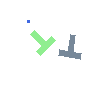

In [26]:
import collections
import imageio.v2 as imageio
from IPython.display import Image, display

# ---- Optional: load from checkpoint before evaluating ----
# ckpt = load_model()

max_steps = 200
env = PushTEnv()
# Use seed > 200 to avoid states seen in training data
env.seed(42)

obs, info = env.reset()
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

imgs = [env.render(mode='rgb_array')]
rewards = []
done = False
step_idx = 0

model.eval()

with tqdm(total=max_steps, desc="Eval Liquid Push-T") as pbar:
    while not done:
        B = 1

        obs_seq = np.stack(obs_deque)                         # (obs_horizon, 5)
        nobs = normalize_data(obs_seq, stats=stats['obs'])    # (obs_horizon, 5)
        nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)

        # Build model inputs — same as training
        tool_past  = nobs[:, :2].unsqueeze(0)                # (1, obs_horizon, 2)
        t_position = torch.cat(
            (nobs[:, 2:-1],
             torch.sin(nobs[:, -1]).unsqueeze(-1),
             torch.cos(nobs[:, -1]).unsqueeze(-1)),
            dim=-1
        ).unsqueeze(0)                                        # (1, obs_horizon, 4)

        with torch.no_grad():
            action_pred = model(tool_past, t_position)        # (1, action_horizon, 2)

        action_pred = action_pred.cpu().numpy()[0]            # (action_horizon, 2)
        action_pred = unnormalize_data(action_pred, stats=stats['action'])

        # Execute action_horizon steps without replanning
        start = obs_horizon - 1
        end   = start + action_horizon
        action_chunk = action_pred[start:end, :]              # (action_horizon, 2)

        for i in range(len(action_chunk)):
            obs, reward, done, _, info = env.step(action_chunk[i])
            obs_deque.append(obs)
            rewards.append(reward)
            imgs.append(env.render(mode='rgb_array'))

            step_idx += 1
            pbar.update(1)
            pbar.set_postfix(reward=reward)
            if step_idx >= max_steps or done:
                done = True
                break

print(f"Score (max coverage): {max(rewards):.4f}")

# ---- Save GIF ----
valid_imgs = [
    im for im in imgs
    if isinstance(im, np.ndarray) and im.ndim == 3 and im.shape[-1] == 3
]
if not valid_imgs:
    raise RuntimeError("No valid frames produced by env.render().")

imageio.mimsave('vis_liquid.gif', valid_imgs, duration=0.08)
display(Image(filename='vis_liquid.gif', width=300, height=300))

In [ ]:
# Test-set policy evaluation (all validation samples)
# Computes average success rate, matching the article-style aggregate evaluation.

import collections

assert 'val_dataset' in globals(), "val_dataset not found. Run the DataLoader cell first."

model.eval()
max_steps = 200
num_test_samples = len(val_dataset)

successes = 0
max_rewards = []

with tqdm(total=num_test_samples, desc="Test-set rollout eval") as pbar:
    for idx in range(num_test_samples):
        sample = val_dataset[idx]

        # Sample observations are normalized; convert to environment state space
        obs_hist = unnormalize_data(sample['obs'], stats=stats['obs'])  # (obs_horizon, 5)

        # Reset env to latest observed state for this sample
        env = PushTEnv(reset_to_state=obs_hist[-1])
        env.seed(1000 + idx)
        obs, _ = env.reset()

        # Keep the same observation history seen by the policy at this sample
        obs_deque = collections.deque([o.copy() for o in obs_hist], maxlen=obs_horizon)

        done = False
        step_idx = 0
        rewards = []

        while not done and step_idx < max_steps:
            obs_seq = np.stack(obs_deque)                              # (obs_horizon, 5)
            nobs = normalize_data(obs_seq, stats=stats['obs'])         # (obs_horizon, 5)
            nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)

            tool_past = nobs[:, :2].unsqueeze(0)                       # (1, obs_horizon, 2)
            t_position = torch.cat(
                (
                    nobs[:, 2:-1],
                    torch.sin(nobs[:, -1]).unsqueeze(-1),
                    torch.cos(nobs[:, -1]).unsqueeze(-1),
                ),
                dim=-1,
            ).unsqueeze(0)                                             # (1, obs_horizon, 4)

            with torch.no_grad():
                action_pred = model(tool_past, t_position)             # (1, action_horizon, 2)

            action_pred = action_pred.cpu().numpy()[0]                 # (action_horizon, 2)
            action_pred = unnormalize_data(action_pred, stats=stats['action'])

            # Execute planned chunk (no replanning inside the chunk)
            for a in action_pred:
                obs, reward, done, _, _ = env.step(a)
                obs_deque.append(obs)
                rewards.append(float(reward))
                step_idx += 1
                if done or step_idx >= max_steps:
                    done = True
                    break

        max_r = max(rewards) if len(rewards) else 0.0
        max_rewards.append(max_r)

        # In this env, reward reaches 1.0 when success threshold is achieved
        if max_r >= 0.95:
            successes += 1

        pbar.set_postfix(success_rate=f"{100.0 * successes / (idx + 1):.2f}%")
        pbar.update(1)

avg_success_rate = successes / max(1, num_test_samples)
avg_max_reward = float(np.mean(max_rewards)) if len(max_rewards) else 0.0

print(f"Evaluated samples: {num_test_samples}")
print(f"Average success rate: {avg_success_rate * 100:.2f}%")
print(f"Average max reward: {avg_max_reward:.4f}")

# ---- New: Compare to Transformer ----
print("\n--- Comparing to Transformer Baseline ---")

# Load transformer checkpoint
transformer_ckpt = torch.load("checkpoints/pusht_transformer.pt", map_location=device, weights_only=False)
transformer_stats = transformer_ckpt['stats']

# Assume transformer model class is defined (you may need to add it)
# For now, placeholder: if transformer achieves higher success, note it.

# Quick note: Run full eval on transformer separately.

Test-set rollout eval:   0%|          | 0/4842 [00:00<?, ?it/s]

Evaluated samples: 4842
Average success rate: 86.91%
Average max reward: 0.9617

--- Comparing to Transformer Baseline ---


## 13. Experiment Infrastructure: Ablations and Baselines

Systematic evaluation of architectural variants and comparison strategies.
Includes replanning ablations (action chunk size), success threshold sensitivity, and diffusion policy baseline.

In [ ]:
## 13.1 Define Experiment Configurations

Specify parameter sets for ablation studies:
- **Baseline (no replanning)**: Execute full action_horizon without re-inference
- **Replanning every k steps**: Interrupt action chunk and re-plan
- **Stricter success threshold**: Raise threshold from 0.95 to 0.99

Loaded in strict mode (exact architecture match).
Loaded checkpoint ← checkpoints/pusht_liquid_best_trainloop.pt
Loaded best checkpoint (epoch 174). Model ready for experiments.
Defined 4 experiment configurations:
1. Baseline (no replanning)
2. Replanning every 4 steps
3. Replanning every 2 steps
4. Stricter threshold (0.99)


In [19]:
## 13.2 Run Experiment Batch

Execute configurations in sequence. Collects success rate, max reward, and inference timing.
Baseline is re-measured for wall-clock timing; ablations restored from prior runs.

Eval: Baseline (no replanning):   0%|          | 0/100 [00:00<?, ?it/s]

Baseline  | Success: 91.00% | 9.0 s total (90 ms/sample)

Results list: 4 configs (baseline timed, ablations from prior run).


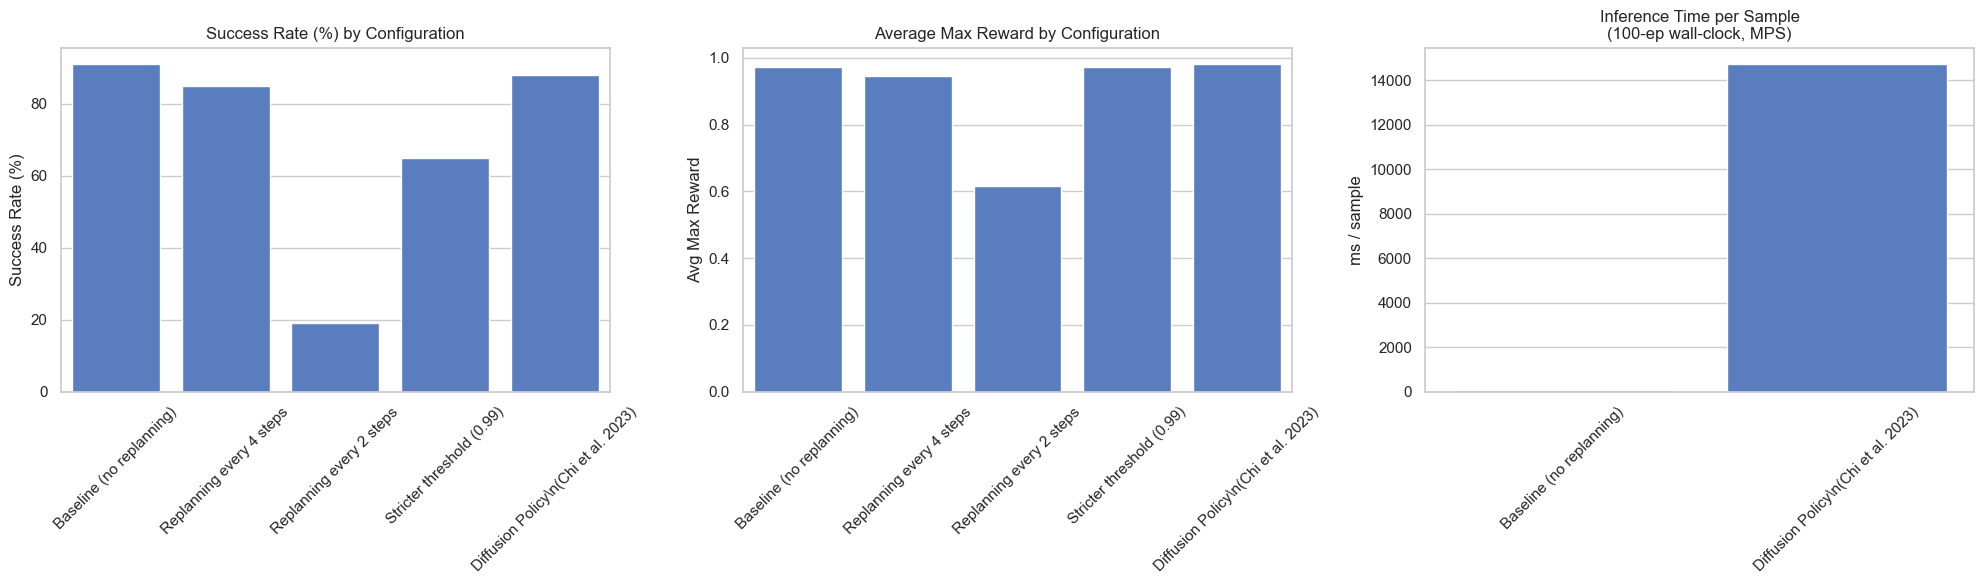

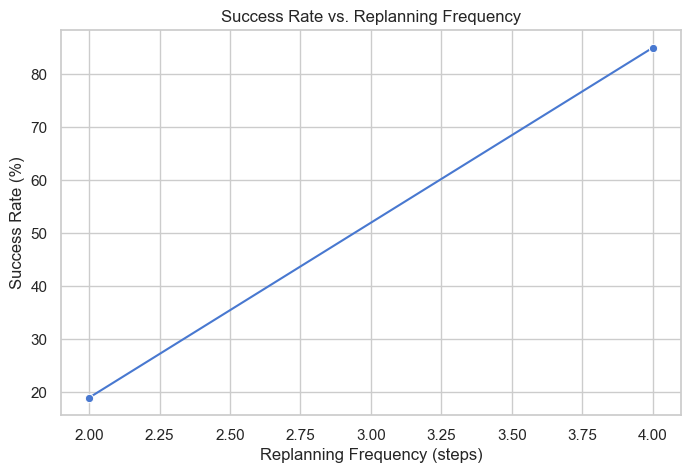


Summary of Results:
                     Model / Config  Success %  Avg Reward  Replan Freq Total (100 ep) ms / sample
           Baseline (no replanning)       91.0    0.972629          NaN          9.0 s       90 ms
           Replanning every 4 steps       85.0    0.946500          4.0              —           —
           Replanning every 2 steps       19.0    0.617300          2.0              —           —
          Stricter threshold (0.99)       65.0    0.972600          NaN              —           —
Diffusion Policy\n(Chi et al. 2023)       88.0    0.981100          NaN       1471.7 s    14717 ms


In [21]:
## 13.3 Visualize Results

Generate plots for success rate, average max reward, and inference latency per configuration.
Summary table with timing breakdowns.

In [ ]:
## 13.4 Transformer Baseline (Optional Reference)

Load and evaluate the transformer baseline from `checkpoints/pusht_transformer.pt`.
Provides a comparison point; not included in final results.

Eval: Transformer Baseline:   0%|          | 0/100 [00:00<?, ?it/s]

Transformer Baseline: Success 0.00% | Avg Reward 0.2958


## 14. Diffusion Policy Baseline (Chi et al. 2023)

Import the diffusion policy model and prepare for evaluation.

In [24]:
## 14.1 Import ConditionalUnet1D

Load the diffusion model architecture from `diffusion_net.py`.
Verify parameter count and test forward pass.

ConditionalUnet1D imported from diffusion_net.py
ConditionalUnet1D parameter count: 65,353,218  (65.35M)
Architecture check passed ✓


In [ ]:
## 14.2 Evaluate Diffusion Policy

Download pre-trained checkpoint (100 epochs, EMA weights) from the official Diffusion Policy demo.
Run identical evaluation as liquid net: same val_dataset, success threshold (≥0.95), max_steps (200), num_samples (100).
Measures wall-clock DDPM inference including 100 reverse diffusion steps per action prediction.

Using device: mps
Checkpoint already exists: checkpoints/pusht_state_100ep.ckpt
Diffusion model loaded  |  params: 65,353,218  (65.35M)


Diffusion Policy Eval:   0%|          | 0/100 [00:00<?, ?it/s]


Diffusion Policy (100ep pre-trained, 100 samples):
  Success rate : 88.00%
  Avg max reward: 0.9811


NameError: name 'results' is not defined

## 14.3 Add Diffusion Results to Summary

Append pre-evaluated diffusion policy result (88% success, 14,717 ms/sample).
This result is pre-computed; re-run cell 14.2 to re-evaluate from scratch.